In [23]:
# importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [24]:
# loading the dataset
df = pd.read_csv('Datasets/final-segment-dataset-2025.csv')

In [25]:

df.head()

,rid,from_station,to_station,late_canc_reason,total_stops_in_run,remaining_stops_after_this,date_of_service,month,day_of_week,day_of_month,...,historical_avg_leg_duration_min,historical_avg_cum_delay_min,historical_avg_arrival_delay_min,delay_historical_difference,from_temp,from_precip,from_wind,to_temp,to_precip,to_wind
0,2.025010e+14,KGX,YRK,696.0,6,5,01/01/2025,1,2,1,...,106.655367,-62.201977,-65.834746,61.201977,6.1,0.8,17.0,4.1,0.0,17.9
1,2.025010e+14,KGX,YRK,NaN,6,5,01/01/2025,1,2,1,...,106.655367,-62.201977,-65.834746,61.201977,5.9,1.2,16.9,3.9,0.0,17.2
2,2.025010e+14,KGX,YRK,NaN,6,5,01/01/2025,1,2,1,...,106.655367,-62.201977,-65.834746,61.201977,6.2,0.2,14.9,3.4,0.0,15.4
3,2.025010e+14,KGX,YRK,NaN,6,5,02/01/2025,1,3,2,...,106.655367,-62.201977,-65.834746,61.201977,3.1,0.0,8.1,0.2,0.0,11.0
4,2.025010e+14,KGX,YRK,NaN,6,5,02/01/2025,1,3,2,...,106.655367,-62.201977,-65.834746,61.201977,2.4,0.0,6.7,0.0,0.0,12.3


In [26]:
df.tail()

,rid,from_station,to_station,late_canc_reason,total_stops_in_run,remaining_stops_after_this,date_of_service,month,day_of_week,day_of_month,...,historical_avg_leg_duration_min,historical_avg_cum_delay_min,historical_avg_arrival_delay_min,delay_historical_difference,from_temp,from_precip,from_wind,to_temp,to_precip,to_wind
11190,2.025120e+14,NCL,EDB,576.0,4,1,29/12/2025,12,0,29,...,NaN,NaN,NaN,NaN,6.7,0.0,7.2,5.0,0.0,12.9
11191,2.025120e+14,NCL,EDB,NaN,4,1,29/12/2025,12,0,29,...,NaN,NaN,NaN,NaN,6.9,0.0,12.5,4.7,0.0,11.9
11192,2.025120e+14,NCL,EDB,841.0,4,1,30/12/2025,12,1,30,...,NaN,NaN,NaN,NaN,2.5,0.0,7.7,0.7,0.0,5.8
11193,2.025120e+14,NCL,EDB,NaN,4,1,30/12/2025,12,1,30,...,NaN,NaN,NaN,NaN,1.8,0.0,7.9,0.3,0.0,6.9
11194,2.025120e+14,NCL,EDB,NaN,4,1,30/12/2025,12,1,30,...,NaN,NaN,NaN,NaN,1.3,0.0,7.3,0.0,0.0,6.1


In [27]:
df.columns

Index(['rid', 'from_station', 'to_station', 'late_canc_reason',
       'total_stops_in_run', 'remaining_stops_after_this', 'date_of_service',
       'month', 'day_of_week', 'day_of_month', 'from_sched_arrival_min',
       'from_actual_arrival_min', 'from_sched_departure_min',
       'from_actual_departure_min', 'to_sched_arrival_min',
       'to_actual_arrival_min', 'to_sched_departure_min',
       'to_actual_departure_min', 'propagated_delay_min',
       'end_segment_delay_min', 'cum_delay_min', 'leg_duration_min',
       'arrival_delay_min', 'prev_train_leg_delay_min',
       'prev_train_cum_delay_min', 'prev_train_segment_duration_min',
       'prev_train_end_segment_delay_min',
       'historical_avg_propagated_delay_min',
       'historical_avg_leg_duration_min', 'historical_avg_cum_delay_min',
       'historical_avg_arrival_delay_min', 'delay_historical_difference',
       'from_temp', 'from_precip', 'from_wind', 'to_temp', 'to_precip',
       'to_wind'],
      dtype='object')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11195 entries, 0 to 11194
Data columns (total 38 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   rid                                  11195 non-null  float64
 1   from_station                         11195 non-null  object 
 2   to_station                           11195 non-null  object 
 3   late_canc_reason                     3721 non-null   float64
 4   total_stops_in_run                   11195 non-null  int64  
 5   remaining_stops_after_this           11195 non-null  int64  
 6   date_of_service                      11195 non-null  object 
 7   month                                11195 non-null  int64  
 8   day_of_week                          11195 non-null  int64  
 9   day_of_month                         11195 non-null  int64  
 10  from_sched_arrival_min               11195 non-null  int64  
 11  from_actual_arrival_min     

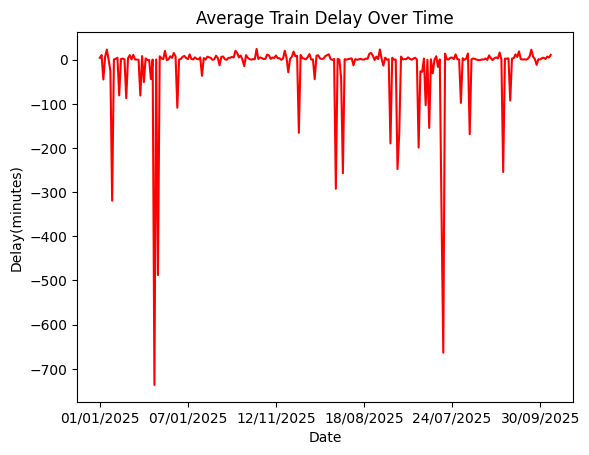

In [29]:
# graph delay over time

# converting the data column to datetime


# grouping by date and get average delays
delay_time = df.groupby('date_of_service')['arrival_delay_min'].mean()

# plot
plt.figure()
delay_time.plot(color = 'red')
plt.title('Average Train Delay Over Time')
plt.xlabel('Date')
plt.ylabel('Delay(minutes)')
plt.show()

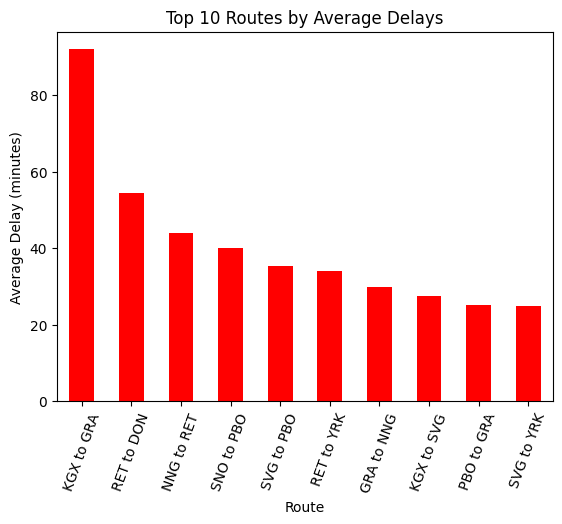

In [30]:

# a route column
df['route'] = df['from_station'] + " to " + df['to_station']

# average delays per route
route_delay = df.groupby('route')['arrival_delay_min'].mean().sort_values(ascending=False).head(10)

#plot
plt.figure()
route_delay.plot(kind='bar', color='red')
plt.title('Top 10 Routes by Average Delays')
plt.xlabel('Route')
plt.ylabel('Average Delay (minutes)')
plt.xticks(rotation=70)
plt.show()


C:\Users\danie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


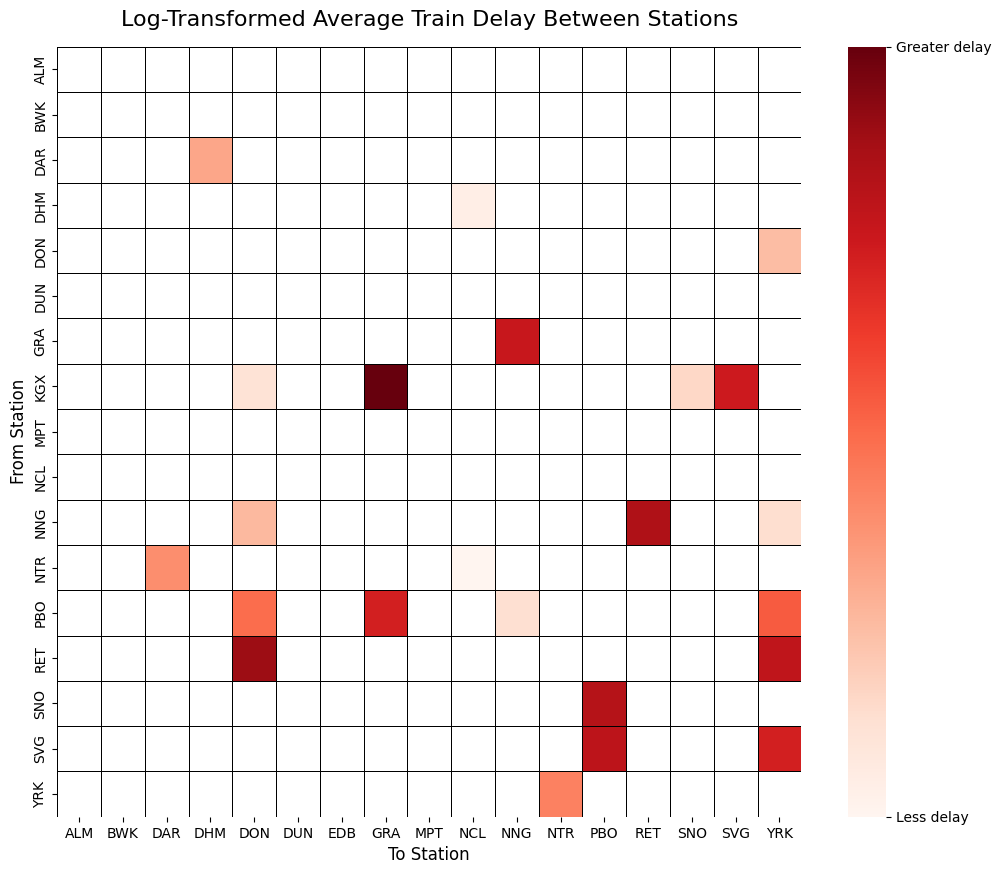

In [31]:
# average delays per route
route_matrix = df.groupby(['from_station','to_station'])['arrival_delay_min'].mean().reset_index()

heatmap_data = route_matrix.pivot(index = 'from_station', columns = 'to_station', values = 'arrival_delay_min')
log_heatmap_data = np.log1p(heatmap_data+1)  # log transformation to handle skewness and improve visualization

plt.figure(figsize=(12,10))

ax = sns.heatmap(
    log_heatmap_data,
    cmap='Reds',
    linewidths=0.5,
    linecolor='black'
)

# Customize colorbar
cbar = ax.collections[0].colorbar
cbar.set_ticks([
    log_heatmap_data.min().min(),
    log_heatmap_data.max().max()
])
cbar.set_ticklabels(['Less delay', 'Greater delay'])

plt.title('Log-Transformed Average Train Delay Between Stations', fontsize=16, pad=15)
plt.xlabel('To Station', fontsize=12)
plt.ylabel('From Station', fontsize=12)
plt.show()



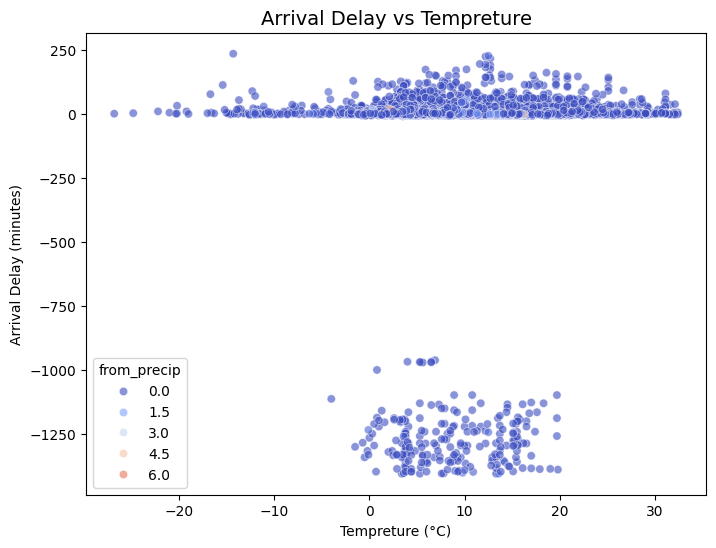

In [32]:
# delay vs tempreture
plt.figure(figsize = (8,6))
sns.scatterplot(
    data = df,
    x = 'from_temp',
    y = 'arrival_delay_min',
    hue = 'from_precip',
    palette = 'coolwarm',
    alpha = 0.6
)

plt.title("Arrival Delay vs Tempreture", fontsize = 14)
plt.xlabel("Tempreture (°C)")
plt.ylabel("Arrival Delay (minutes)")
plt.show()


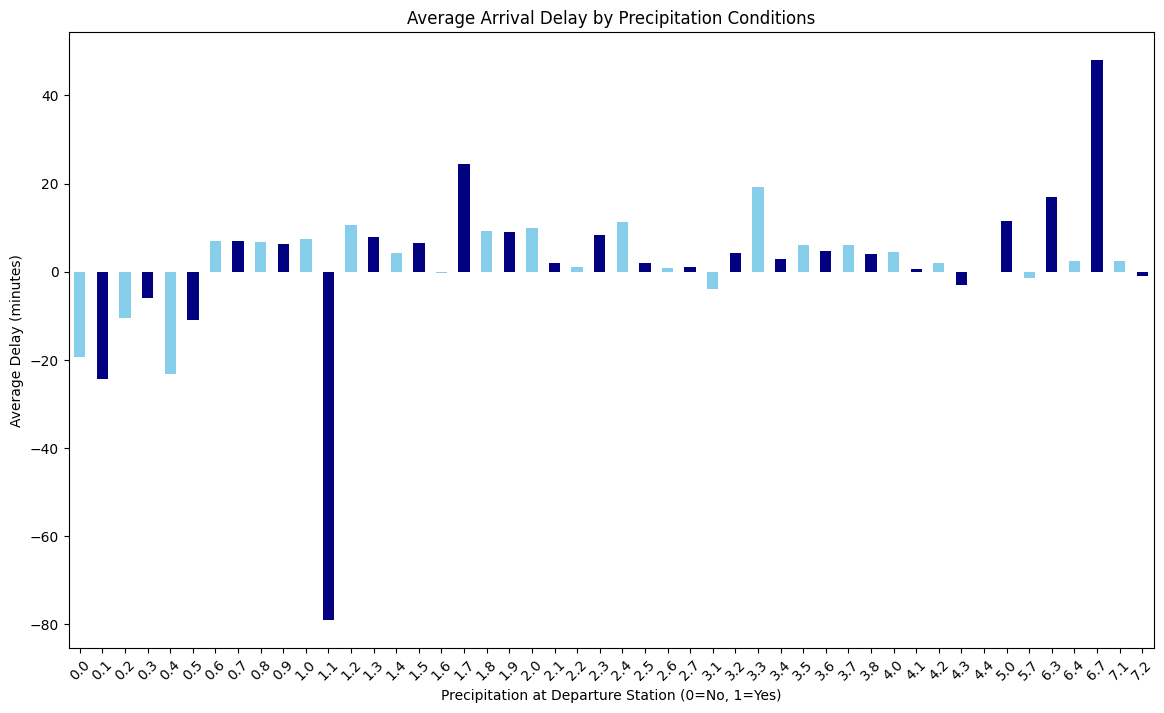

In [33]:
# rain vs average delay
plt.figure(figsize = (14,8))

rain_delay = df.groupby("from_precip")['arrival_delay_min'].mean()
rain_delay.plot(kind = 'bar', color= ['skyblue', 'navy'])
plt.title("Average Arrival Delay by Precipitation Conditions")
plt.xlabel("Precipitation at Departure Station (0=No, 1=Yes)")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.show()
# 0 is sky blue
# 1 is navy
# bar a 0 (sky blue) shows the average delays for trains that departed when it was not raining
# bar at 1 (navy) shows the average delays for trains that departed when it was raining.